In [4]:
import requests
from io import StringIO
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1) Get lake id

You can find the a lake id in hydroweb in the Apriori Lake database.

Bellow some example over the French Alps:
Lac Arsigne: 2160023152
Lac Serpenson: 2160015863
Lac du Broc: 2160023372
Lac du Cap Long : 2320040532
Lac des Gloriette : 2320042682
Lac de Joux: 2320148662

In [5]:
lake_id = 2320148662
start_time = "2022-01-01T00:00:00"
end_time = "2025-06-30T00:00:00"

# 2) Submission of the request

In [6]:
hydrocron_response = requests.get(
    f"https://soto.podaac.earthdatacloud.nasa.gov/hydrocron/v1/timeseries?feature=PriorLake&feature_id={lake_id}&start_time={start_time}Z&end_time={end_time}Z&output=csv&fields=time_str,wse,area_total,lake_name,wse_u,layovr_val,area_tot_u,xtrk_dist,quality_f,dark_frac,xovr_cal_q"
).json()
hydrocron_response

{'status': '200 OK',
 'time': 2273.801,
 'hits': 228,
 'results': {'csv': 'time_str,wse,area_total,lake_name,wse_u,layovr_val,area_tot_u,xtrk_dist,quality_f,dark_frac,xovr_cal_q,wse_units,area_total_units,wse_u_units,layovr_val_units,area_tot_u_units,xtrk_dist_units,dark_frac_units\n2023-03-29T00:23:26Z,1003.963,8.812027,LAC DE JOUX,0.268,0.158,0.015103,-30786.875,3,0.152434,2,m,km^2,m,TBD,km^2,m,1\n2023-03-30T00:14:04Z,1004.575,8.348887,LAC DE JOUX,0.079,0.14,0.013475,-30726.048,3,0.333239,2,m,km^2,m,TBD,km^2,m,1\n2023-03-31T00:04:41Z,1003.506,9.054932,LAC DE JOUX,0.401,0.119,0.015263,-30995.368,0,0.029946,0,m,km^2,m,TBD,km^2,m,1\n2023-04-01T23:45:57Z,1003.321,8.810627,LAC DE JOUX,0.49,0.14,0.014777,-30961.943,0,0.03121,0,m,km^2,m,TBD,km^2,m,1\nno_data,-999999999999.0,-999999999999.0,LAC DE JOUX,-999999999999.0,-999999999999.0,-999999999999.0,-999999999999.0,-999,-999999999999.0,-999,m,km^2,m,TBD,km^2,m,1\n2023-04-03T23:27:12Z,1003.744,9.123293,LAC DE JOUX,0.328,0.141,0.01563,-31059.8

In [7]:
csv_str = hydrocron_response['results']['csv']

# 3) Conversion to pandas dataframe

In [8]:
df = pd.read_csv(StringIO(csv_str))
df = df[df['time_str']!='no_data']
df.time_str = pd.to_datetime(df.time_str)
df.reset_index(drop=True, inplace=True)
df# df

,time_str,wse,area_total,lake_name,wse_u,layovr_val,area_tot_u,xtrk_dist,quality_f,dark_frac,xovr_cal_q,wse_units,area_total_units,wse_u_units,layovr_val_units,area_tot_u_units,xtrk_dist_units,dark_frac_units
0,2023-03-29 00:23:26+00:00,1003.963,8.812027,LAC DE JOUX,0.268,0.158,0.015103,-30786.875,3,0.152434,2,m,km^2,m,TBD,km^2,m,1
1,2023-03-30 00:14:04+00:00,1004.575,8.348887,LAC DE JOUX,0.079,0.140,0.013475,-30726.048,3,0.333239,2,m,km^2,m,TBD,km^2,m,1
2,2023-03-31 00:04:41+00:00,1003.506,9.054932,LAC DE JOUX,0.401,0.119,0.015263,-30995.368,0,0.029946,0,m,km^2,m,TBD,km^2,m,1
3,2023-04-01 23:45:57+00:00,1003.321,8.810627,LAC DE JOUX,0.490,0.140,0.014777,-30961.943,0,0.031210,0,m,km^2,m,TBD,km^2,m,1
4,2023-04-03 23:27:12+00:00,1003.744,9.123293,LAC DE JOUX,0.328,0.141,0.015630,-31059.851,0,0.009203,0,m,km^2,m,TBD,km^2,m,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,2025-05-30 20:39:05+00:00,1003.684,1.009794,LAC DE JOUX,0.035,0.064,0.039731,-10998.016,1,0.068573,0,m,km^2,m,TBD,km^2,m,1
187,2025-06-07 05:41:09+00:00,1003.909,8.741849,LAC DE JOUX,0.003,0.021,0.013074,45046.418,0,0.005612,0,m,km^2,m,TBD,km^2,m,1
188,2025-06-18 04:04:00+00:00,1004.190,8.159160,LAC DE JOUX,0.005,0.008,0.008829,-45724.210,1,0.421335,0,m,km^2,m,TBD,km^2,m,1
189,2025-06-20 17:24:09+00:00,1005.214,5.798472,LAC DE JOUX,0.358,0.039,0.142091,-6678.754,3,0.000198,2,m,km^2,m,TBD,km^2,m,1


In [9]:
df.loc[df['wse_u'] < 0, 'wse_u'] = np.nan #remove values with uncertainties lower than 0

# 4) Vizualisation

Text(0.5, 1.0, 'Water Surface Elevation from Hydrocron for Lake: LAC DE JOUX')

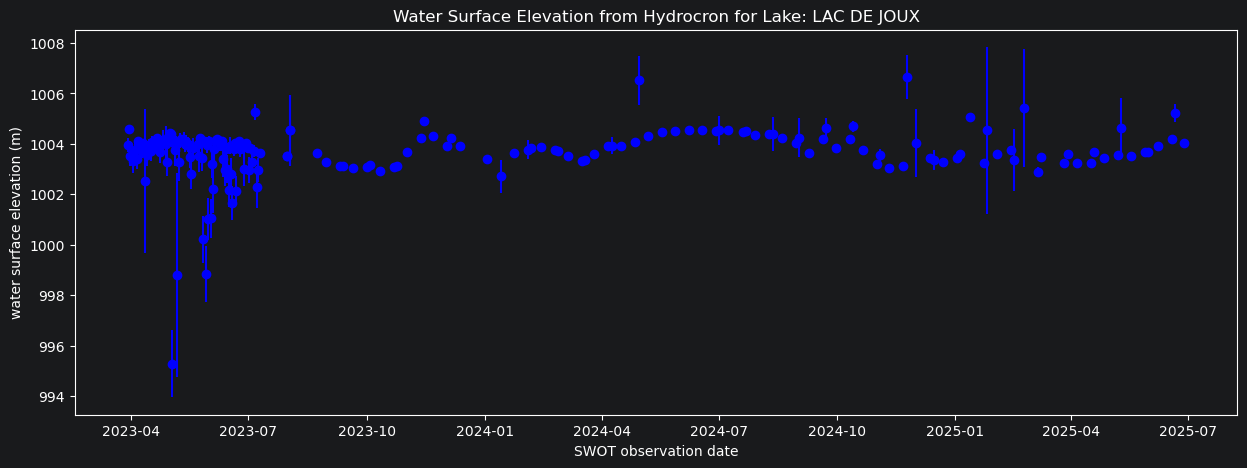

In [10]:
fig, ax = plt.subplots(figsize=(15, 5))
# ax.set_ylim(2400, 2500)
ax.errorbar(df.time_str, df.wse,
                yerr=df.wse_u, color='b',
                alpha=1, fmt=',', zorder=1)
ax.plot(df.time_str, df.wse, marker='o',linestyle='', color='b')

plt.ylabel(f'water surface elevation ({df.wse_units.iloc[0]})')
plt.xlabel('SWOT observation date')
plt.title('Water Surface Elevation from Hydrocron for Lake: ' + str(df.lake_name.iloc[0]))


Text(0.5, 1.0, 'Water Surface Area from Hydrocron for Lake: LAC DE JOUX')

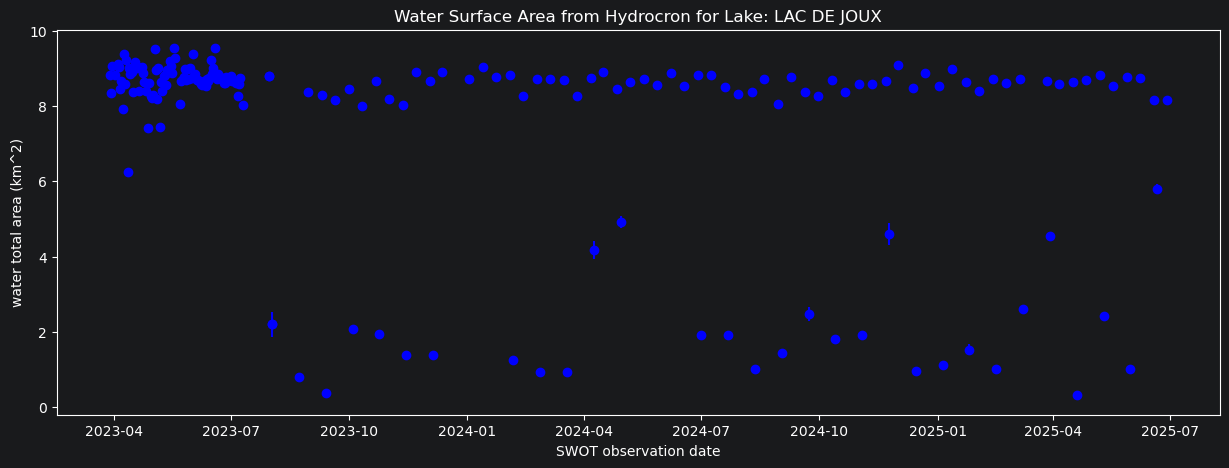

In [11]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.time_str, df.area_total, marker='o',linestyle='', color='b')
ax.errorbar(df.time_str, df.area_total,
                yerr=df.area_tot_u, color='b',
                alpha=1, fmt=',', zorder=1)
plt.ylabel(f'water total area ({df.area_total_units.iloc[0]})')
plt.xlabel('SWOT observation date')

plt.title('Water Surface Area from Hydrocron for Lake: ' + str(df.lake_name.iloc[0]))

# 5) Save csv file (optional)

In [12]:
# path_save = ""
# df.to_csv(f'{path_save}/SP_wse.csv', index=False)